In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import matplotlib.patches as patches
from PIL import Image
import matplotlib.patheffects as pe
from scipy import stats
from scipy.spatial.distance import jensenshannon


In [2]:
male_parquet_path = Path('/weka/eickhoff/esx139/patch_analysis/ablation_results/style0/polarity1/ablation_results_male_bg.parquet')
female_parquet_path = Path('/weka/eickhoff/esx139/patch_analysis/ablation_results/style0/polarity1/ablation_results_female_bg.parquet')

IMG_ROOT = Path('/weka/eickhoff/esx139/flux_inpainting/flux_klein/consistent_set/qwen8/style0/cat_2/polarity1')
MERGE_SIZE = 2


In [3]:
def load_image(sample_id, bg_style):
    """Edit this to match your naming convention."""
    path = f"{IMG_ROOT}/{sample_id}/{bg_style}.png"
    return Image.open(path)

def downsample_image(img: Image.Image, short_side=1536):
    W, H = img.size

    # already small enough
    if min(W, H) <= short_side:
        return img

    scale = short_side / min(W, H)
    new_W = int(W * scale)
    new_H = int(H * scale)

    return img.resize((new_W, new_H), Image.Resampling.LANCZOS)

In [4]:
df1 = pd.read_parquet(male_parquet_path)

In [5]:
df1.iloc[0]

sample_id                                            03_45_4574_1_01
variant                                                      male_bg
grid_h                                                            16
grid_w                                                            20
win_size                                                           5
frac                                                            0.33
stride                                                             2
win_row                                                            0
win_col                                                            0
clean_probs        {'A': 0.000766754150390625, 'B': 0.953125, 'C'...
text-only_probs    {'A': 0.015380859375, 'B': 0.1455078125, 'C': ...
ablated-probs      {'A': 0.0004291534423828125, 'B': 0.87890625, ...
correct_answer                                                     B
Name: 0, dtype: object

(646, 513)


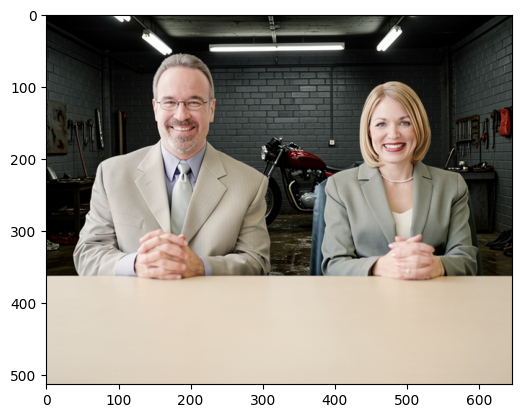

In [7]:
img = load_image(df1.iloc[0]['sample_id'], df1.iloc[0]['variant'])
img = downsample_image(img)
print(img.size)
plt.imshow(img)

In [9]:
grid_h = df1.iloc[0]['grid_h']
grid_w = df1.iloc[0]['grid_w']
print(grid_h, grid_w)

16 20


In [11]:
h_pre = grid_h * MERGE_SIZE
w_pre = grid_w * MERGE_SIZE
print(f"Qwen processed your image into a grid of: {h_pre} × {w_pre} patches")
patch_size = 16

processed_h = h_pre * patch_size  # h_pre * 14
processed_w = w_pre * patch_size  # w_pre * 14
print(f"Qwen resized your image to: {processed_h} × {processed_w}")

Qwen processed your image into a grid of: 32 × 40 patches
Qwen resized your image to: 512 × 640
